<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Quantum_Acceleration_Assessment_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [3]:
!apt-get update -qq
!apt-get install -y -qq graphviz fonts-dejavu-core
!python -m pip install -q uv
!uv pip install --system -q graphviz
!fc-cache -f

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Setting up fonts-dejavu-core (2.37-2build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.1/27.1 MB 54.5 MB/s eta 0:00:00


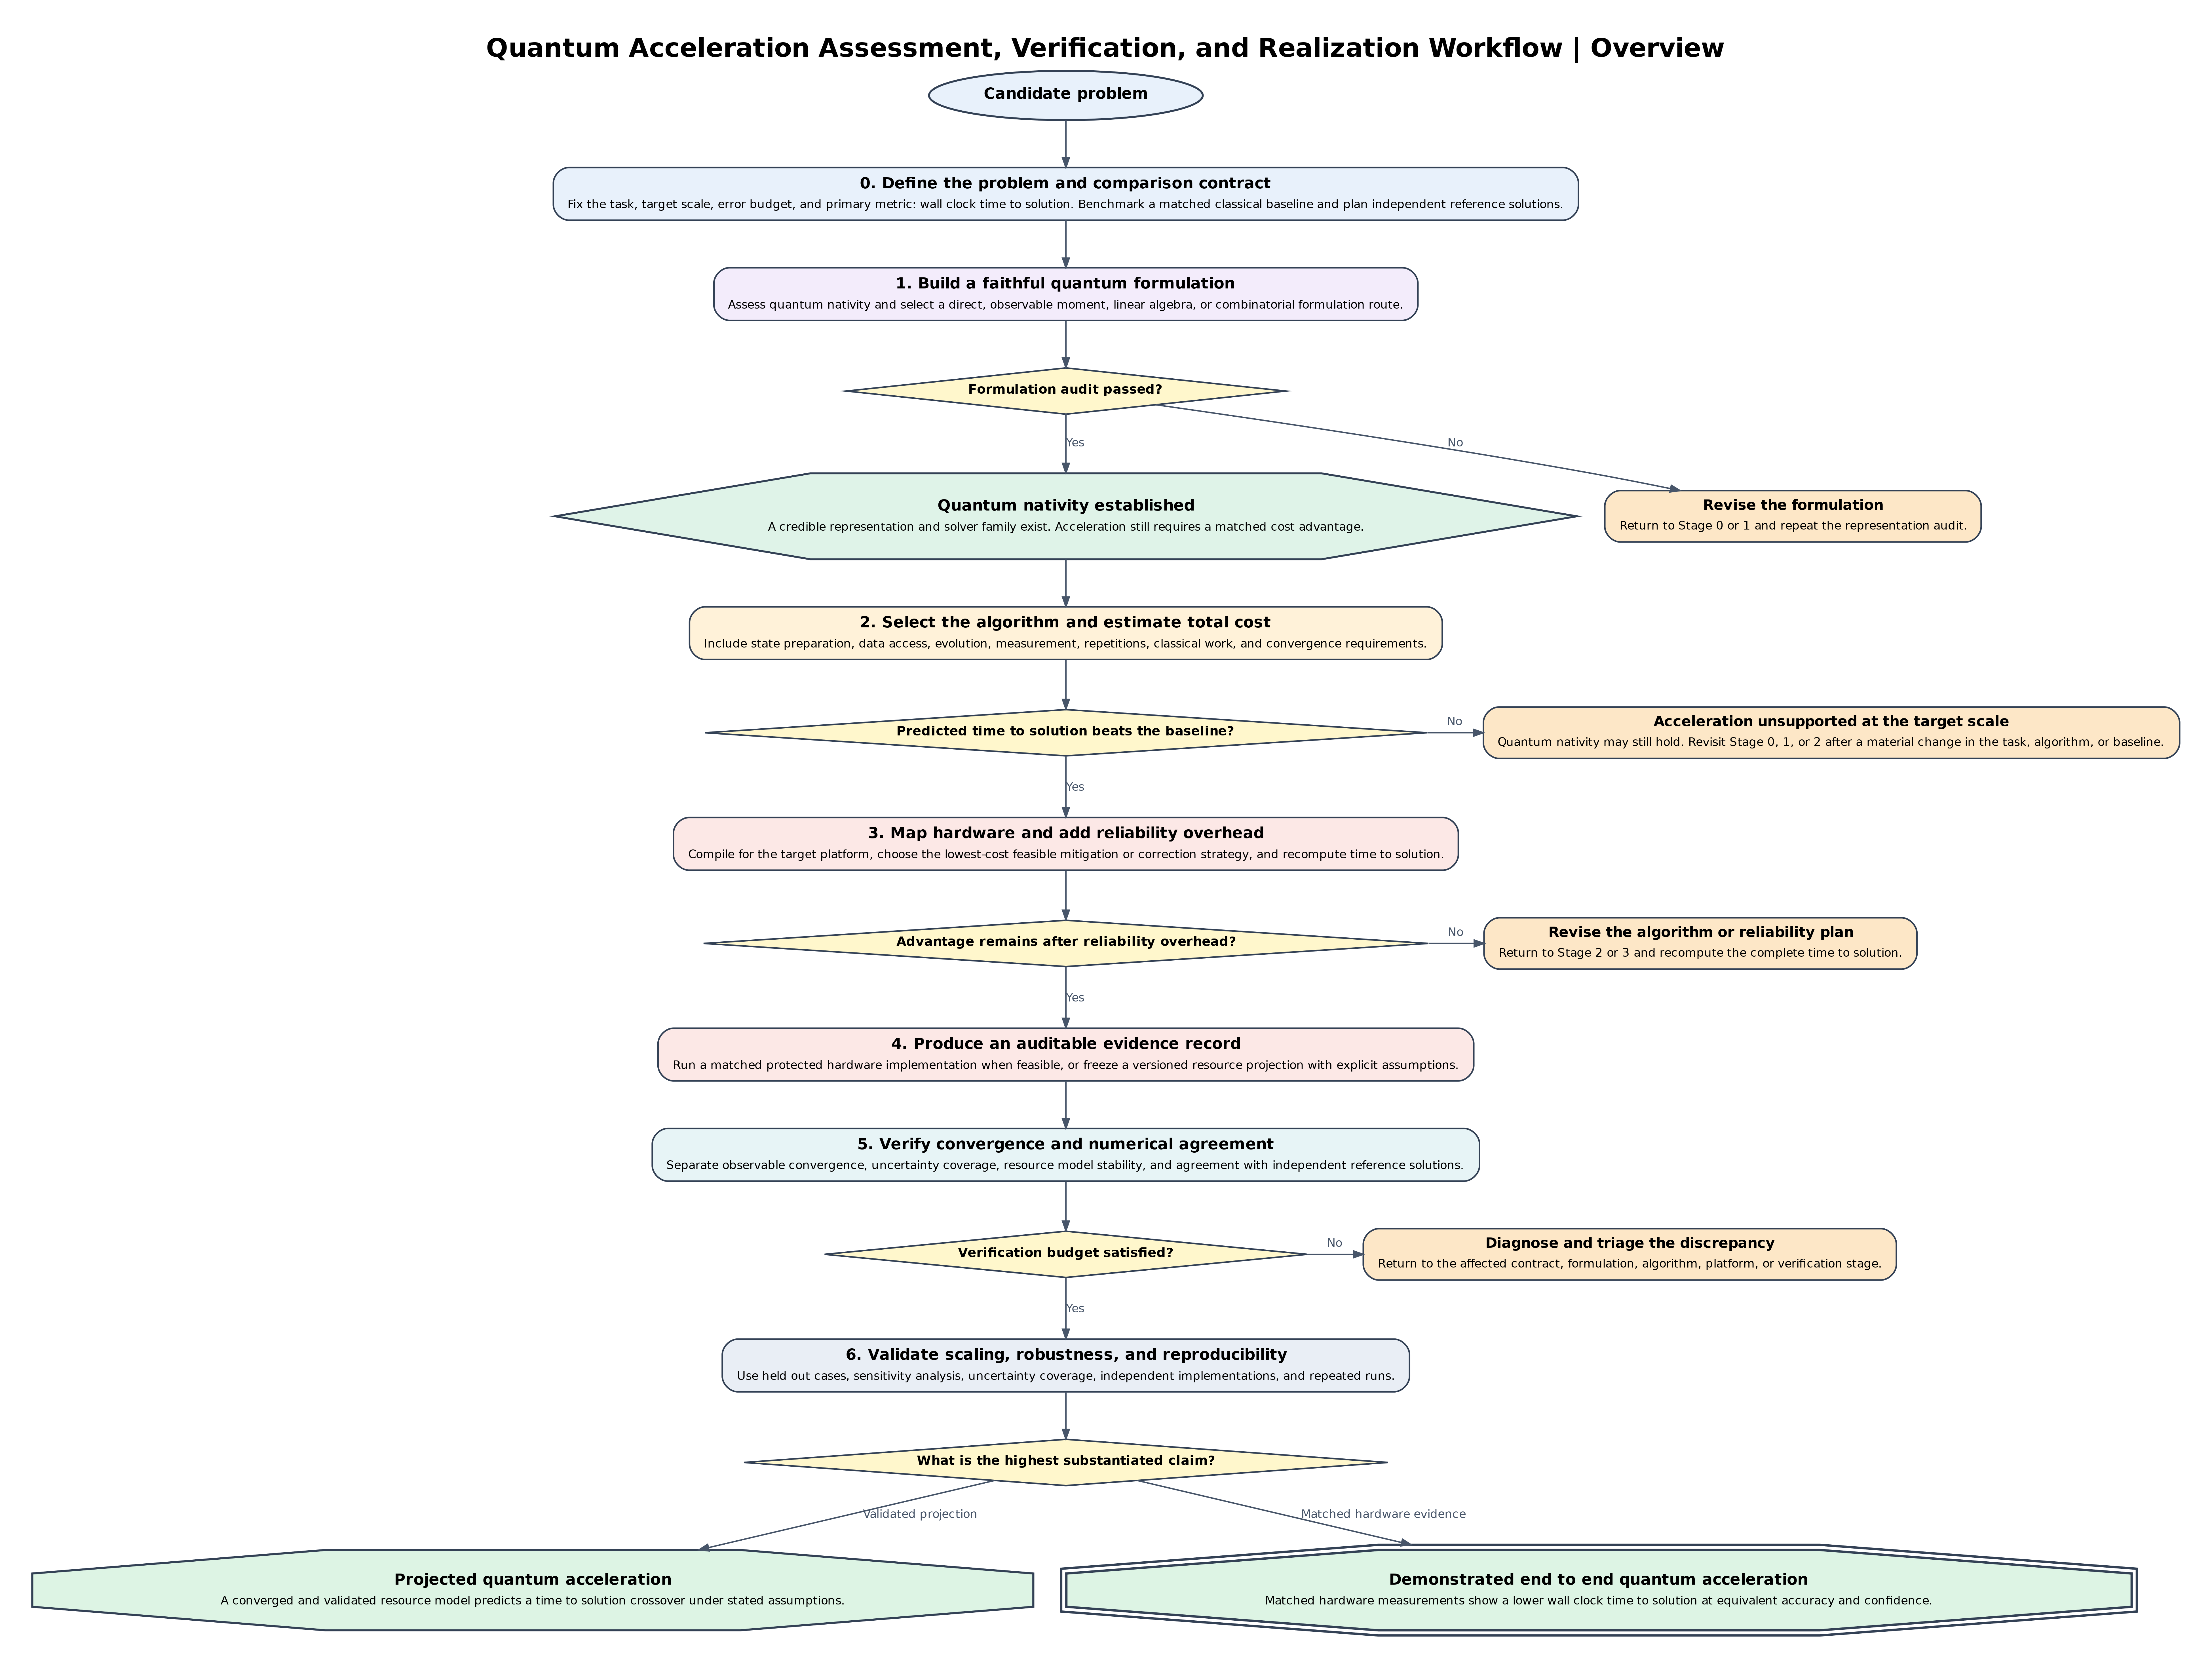

Acronym,Expansion,Acronym,Expansion
HPC,High performance computing,QLSA,Quantum linear systems algorithm
QSVT,Quantum singular value transformation,QUBO,Quadratic unconstrained binary optimization
QEM,Quantum error mitigation,ZNE,Zero noise extrapolation
PEC,Probabilistic error cancellation,QEC,Quantum error correction


In [6]:
"""Render a quantum acceleration assessment workflow with convergence verification."""

import html
import subprocess
import unicodedata
from typing import Literal

from graphviz import Digraph
from graphviz.backend import ExecutableNotFound
from IPython.display import HTML, Image, display

# Control knobs for easy parameter adjustment.
ViewMode = Literal["overview", "detailed", "both"]
OutputFormat = Literal["svg", "png"]

VIEW_MODE: ViewMode = "both"
OUTPUT_FORMAT: OutputFormat = "png"
GRAPH_TITLE: str = (
    "Quantum Acceleration Assessment, Verification, and Realization Workflow"
)
PRIMARY_COMPARISON_METRIC: str = "wall clock time to solution"
RANK_DIRECTION: str = "TB"
FONT_NAME: str = "DejaVu Sans"
GRAPHVIZ_CHARSET: str = "UTF-8"
PNG_RENDERER: str = "cairo"
RASTER_DPI: int = 600
USE_ASCII_DOT_SOURCE: bool = True
SHOW_READING_KEY: bool = True

OVERVIEW_MAX_SIZE_IN: str = "13,16"
DETAILED_MAX_SIZE_IN: str = "18,28"
OVERVIEW_SVG_MIN_WIDTH_PX: int = 1200
DETAILED_SVG_MIN_WIDTH_PX: int = 1900
SCROLL_CONTAINER_MAX_HEIGHT_PX: int = 1200

OVERVIEW_TITLE_SIZE: int = 12
OVERVIEW_DETAIL_SIZE: int = 9
DETAILED_TITLE_SIZE: int = 11
DETAILED_DETAIL_SIZE: int = 9
DECISION_TITLE_SIZE: int = 10
DECISION_DETAIL_SIZE: int = 8
EDGE_FONT_SIZE: int = 9
CLUSTER_FONT_SIZE: int = 13
GRAPH_TITLE_SIZE: int = 20

PALETTE: dict[str, str] = {
    "contract": "#E8F1FB",
    "nativity": "#E8F7F0",
    "mapping": "#F3ECFB",
    "advantage": "#FFF2D9",
    "platform": "#FCE8E6",
    "verification": "#E7F4F6",
    "validation": "#E9EEF5",
    "decision": "#FFF7CC",
    "milestone": "#DFF3E8",
    "terminal_good": "#DDF4E4",
    "terminal_review": "#FDE7C7",
    "terminal_stop": "#F5D7D7",
    "note": "#F8FAFC",
    "border": "#334155",
    "edge": "#475569",
    "feedback": "#64748B",
}

CLUSTER_COLORS: dict[str, str] = {
    "contract": "#8FB3D9",
    "nativity": "#7EB69A",
    "advantage": "#C1A367",
    "platform": "#D58E86",
    "verification": "#70AAB3",
    "validation": "#94A3B8",
    "legend": "#CBD5E1",
}


def encode_graphviz_text(text: str, *, alignment: str = "CENTER") -> str:
    """Escape text and preserve Unicode safely in HTML-like Graphviz labels.

    Args:
        text: Human-readable text.
        alignment: Graphviz line-break alignment.

    Returns:
        ASCII-safe HTML content for a Graphviz label.
    """
    normalized_text = unicodedata.normalize("NFC", text)
    escaped_text = html.escape(normalized_text, quote=False)

    encoded_parts: list[str] = []
    for character in escaped_text:
        if character == "\n":
            encoded_parts.append(f'<BR ALIGN="{alignment}"/>')
        elif USE_ASCII_DOT_SOURCE and ord(character) > 127:
            encoded_parts.append(f"&#x{ord(character):X};")
        else:
            encoded_parts.append(character)

    return "".join(encoded_parts)


def make_text_label(
    text: str,
    *,
    font_size: int,
    bold: bool = False,
    alignment: str = "CENTER",
) -> str:
    """Create a single-style Graphviz HTML-like text label.

    Args:
        text: Human-readable text.
        font_size: Font size in points.
        bold: Whether to use bold text.
        alignment: Line-break alignment.

    Returns:
        A Graphviz HTML-like label string.
    """
    encoded_text = encode_graphviz_text(text, alignment=alignment)
    escaped_font_name = html.escape(FONT_NAME, quote=True)
    if bold:
        encoded_text = f"<B>{encoded_text}</B>"
    return (
        f'<<FONT FACE="{escaped_font_name}" '
        f'POINT-SIZE="{font_size}">{encoded_text}</FONT>>'
    )


def make_node_label(
    title: str,
    detail: str = "",
    *,
    title_size: int = DETAILED_TITLE_SIZE,
    detail_size: int = DETAILED_DETAIL_SIZE,
    alignment: str = "CENTER",
) -> str:
    """Create a two-level node label with a bold action and smaller detail.

    Args:
        title: Short action, gate, milestone, or supported claim.
        detail: Supporting criteria or examples.
        title_size: Title font size in points.
        detail_size: Detail font size in points.
        alignment: Text alignment inside the node.

    Returns:
        A Graphviz HTML-like table label.
    """
    escaped_font_name = html.escape(FONT_NAME, quote=True)
    encoded_title = encode_graphviz_text(title, alignment=alignment)
    encoded_detail = encode_graphviz_text(detail, alignment=alignment)

    rows = [
        "<TR>",
        f'<TD ALIGN="{alignment}" BALIGN="{alignment}">',
        f'<FONT FACE="{escaped_font_name}" POINT-SIZE="{title_size}">',
        f"<B>{encoded_title}</B>",
        "</FONT>",
        "</TD>",
        "</TR>",
    ]
    if detail:
        rows.extend(
            [
                "<TR><TD HEIGHT=\"4\"></TD></TR>",
                "<TR>",
                f'<TD ALIGN="{alignment}" BALIGN="{alignment}">',
                (
                    f'<FONT FACE="{escaped_font_name}" '
                    f'POINT-SIZE="{detail_size}">{encoded_detail}</FONT>'
                ),
                "</TD>",
                "</TR>",
            ]
        )

    table_body = "".join(rows)
    return (
        "<<TABLE BORDER=\"0\" CELLBORDER=\"0\" CELLSPACING=\"0\" "
        f"CELLPADDING=\"0\">{table_body}</TABLE>>"
    )


def add_workflow_node(
    graph: Digraph,
    node_id: str,
    title: str,
    detail: str = "",
    *,
    fill_color: str,
    shape: str = "box",
    pen_width: str = "1.2",
    title_size: int = DETAILED_TITLE_SIZE,
    detail_size: int = DETAILED_DETAIL_SIZE,
    margin: str = "0.15,0.10",
) -> None:
    """Add one consistently styled workflow node.

    Args:
        graph: Graphviz graph or subgraph.
        node_id: Stable node identifier.
        title: Bold action, gate, milestone, or supported claim.
        detail: Supporting criteria or examples.
        fill_color: Node background color.
        shape: Graphviz node shape.
        pen_width: Border width as a Graphviz string.
        title_size: Title font size in points.
        detail_size: Detail font size in points.
        margin: Horizontal and vertical node margin.
    """
    node_style = "rounded,filled" if shape == "box" else "filled"
    graph.node(
        node_id,
        make_node_label(
            title,
            detail,
            title_size=title_size,
            detail_size=detail_size,
        ),
        shape=shape,
        style=node_style,
        fillcolor=fill_color,
        color=PALETTE["border"],
        penwidth=pen_width,
        fontname=FONT_NAME,
        margin=margin,
    )


def add_edge(
    graph: Digraph,
    tail_name: str,
    head_name: str,
    label: str = "",
    *,
    style: str = "solid",
    color: str | None = None,
    constraint: bool = True,
    pen_width: str = "1.1",
) -> None:
    """Add a consistently styled edge.

    Args:
        graph: Graphviz directed graph.
        tail_name: Source node identifier.
        head_name: Destination node identifier.
        label: Optional edge label.
        style: Graphviz edge style.
        color: Optional edge color override.
        constraint: Whether the edge participates in rank assignment.
        pen_width: Edge width as a Graphviz string.
    """
    edge_color = color or PALETTE["edge"]
    attributes: dict[str, str] = {
        "style": style,
        "color": edge_color,
        "fontcolor": edge_color,
        "penwidth": pen_width,
        "constraint": "true" if constraint else "false",
    }
    if label:
        attributes["label"] = make_text_label(
            label,
            font_size=EDGE_FONT_SIZE,
        )
    graph.edge(tail_name, head_name, **attributes)


def style_cluster(cluster: Digraph, label: str, color: str) -> None:
    """Apply the shared visual style to one workflow cluster.

    Args:
        cluster: Graphviz subgraph representing a workflow stage.
        label: Cluster heading.
        color: Cluster border color.
    """
    cluster.attr(
        label=make_text_label(label, font_size=CLUSTER_FONT_SIZE, bold=True),
        color=color,
        fontcolor=PALETTE["border"],
        fontname=FONT_NAME,
        penwidth="1.4",
        style="rounded",
        margin="16",
    )


def configure_graph(
    graph: Digraph,
    *,
    title: str,
    max_size_in: str,
    nodesep: str,
    ranksep: str,
) -> None:
    """Apply global graph and edge attributes.

    Args:
        graph: Graphviz directed graph.
        title: Figure title.
        max_size_in: Maximum drawing size in inches.
        nodesep: Horizontal node separation.
        ranksep: Vertical rank separation.
    """
    graph_attributes: dict[str, str] = {
        "label": make_text_label(
            title,
            font_size=GRAPH_TITLE_SIZE,
            bold=True,
        ),
        "charset": GRAPHVIZ_CHARSET,
        "labelloc": "t",
        "labeljust": "c",
        "rankdir": RANK_DIRECTION,
        "bgcolor": "white",
        "fontname": FONT_NAME,
        "pad": "0.35",
        "nodesep": nodesep,
        "ranksep": ranksep,
        "splines": "spline",
        "compound": "true",
        "newrank": "true",
        "remincross": "true",
        "size": max_size_in,
    }
    if OUTPUT_FORMAT == "png":
        graph_attributes["dpi"] = str(RASTER_DPI)

    graph.attr("graph", **graph_attributes)
    graph.attr(
        "edge",
        color=PALETTE["edge"],
        fontcolor=PALETTE["edge"],
        fontname=FONT_NAME,
        fontsize=str(EDGE_FONT_SIZE),
        arrowsize="0.75",
        penwidth="1.1",
    )


def add_local_revision_node(
    graph: Digraph,
    node_id: str,
    title: str,
    detail: str,
) -> None:
    """Add an amber local revision node that avoids long return arrows.

    Args:
        graph: Graphviz graph or subgraph.
        node_id: Stable node identifier.
        title: Short revision action.
        detail: Explicit stages that should be revisited.
    """
    add_workflow_node(
        graph,
        node_id,
        title,
        detail,
        fill_color=PALETTE["terminal_review"],
        shape="box",
        title_size=DETAILED_TITLE_SIZE,
        detail_size=DETAILED_DETAIL_SIZE,
    )


def make_reading_key_html() -> str:
    """Create the companion glossary and visual-grammar panel.

    Returns:
        HTML for display below the workflow views.
    """
    return """
    <div style="margin-top: 14px; border: 1px solid #CBD5E1;
                border-radius: 6px; padding: 12px; background: #F8FAFC;">
      <h4 style="margin: 0 0 8px 0;">Reading key</h4>
      <p style="margin: 4px 0 8px 0;">
        <strong>Quantum nativity</strong> is a multidimensional fit across
        representation, dynamics, data access, readout, enabling quantum
        resource, and hardware compatibility. It is an intermediate milestone,
        and remains separate from an acceleration claim. Acceleration still requires matched cost evidence.
      </p>
      <table style="border-collapse: collapse; width: 100%; font-size: 0.92em;">
        <tr>
          <th style="text-align: left; padding: 5px; border-bottom: 1px solid #CBD5E1;">
            Acronym
          </th>
          <th style="text-align: left; padding: 5px; border-bottom: 1px solid #CBD5E1;">
            Expansion
          </th>
          <th style="text-align: left; padding: 5px; border-bottom: 1px solid #CBD5E1;">
            Acronym
          </th>
          <th style="text-align: left; padding: 5px; border-bottom: 1px solid #CBD5E1;">
            Expansion
          </th>
        </tr>
        <tr>
          <td style="padding: 4px;"><strong>HPC</strong></td>
          <td style="padding: 4px;">High performance computing</td>
          <td style="padding: 4px;"><strong>QLSA</strong></td>
          <td style="padding: 4px;">Quantum linear systems algorithm</td>
        </tr>
        <tr>
          <td style="padding: 4px;"><strong>QSVT</strong></td>
          <td style="padding: 4px;">Quantum singular value transformation</td>
          <td style="padding: 4px;"><strong>QUBO</strong></td>
          <td style="padding: 4px;">Quadratic unconstrained binary optimization</td>
        </tr>
        <tr>
          <td style="padding: 4px;"><strong>QEM</strong></td>
          <td style="padding: 4px;">Quantum error mitigation</td>
          <td style="padding: 4px;"><strong>ZNE</strong></td>
          <td style="padding: 4px;">Zero noise extrapolation</td>
        </tr>
        <tr>
          <td style="padding: 4px;"><strong>PEC</strong></td>
          <td style="padding: 4px;">Probabilistic error cancellation</td>
          <td style="padding: 4px;"><strong>QEC</strong></td>
          <td style="padding: 4px;">Quantum error correction</td>
        </tr>
      </table>
      <p style="margin: 8px 0 0 0;">
        Rounded boxes are actions. Diamonds are gates. Amber boxes require
        revision. Green shapes state supported milestones or claims. Local
        return instructions replace long feedback arcs.
      </p>
    </div>
    """


def build_overview_workflow() -> Digraph:
    """Build a compact workflow for rapid human scanning.

    Returns:
        A configured overview graph.
    """
    graph = Digraph(
        name="quantum_acceleration_workflow_overview",
        format=OUTPUT_FORMAT,
        encoding="utf-8",
    )
    configure_graph(
        graph,
        title=f"{GRAPH_TITLE} | Overview",
        max_size_in=OVERVIEW_MAX_SIZE_IN,
        nodesep="0.30",
        ranksep="0.48",
    )

    add_workflow_node(
        graph,
        "overview_start",
        "Candidate problem",
        fill_color=PALETTE["contract"],
        shape="ellipse",
        pen_width="1.5",
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_contract",
        "0. Define the problem and comparison contract",
        f"Fix the task, target scale, error budget, and primary metric: "
        f"{PRIMARY_COMPARISON_METRIC}. Benchmark a matched classical baseline "
        "and plan independent reference solutions.",
        fill_color=PALETTE["contract"],
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_formulation",
        "1. Build a faithful quantum formulation",
        "Assess quantum nativity and select a direct, observable moment, "
        "linear algebra, or combinatorial formulation route.",
        fill_color=PALETTE["mapping"],
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_representation_gate",
        "Formulation audit passed?",
        fill_color=PALETTE["decision"],
        shape="diamond",
        title_size=DECISION_TITLE_SIZE,
        detail_size=DECISION_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_nativity",
        "Quantum nativity established",
        "A credible representation and solver family exist. Acceleration "
        "still requires a matched cost advantage.",
        fill_color=PALETTE["milestone"],
        shape="hexagon",
        pen_width="1.5",
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_algorithm",
        "2. Select the algorithm and estimate total cost",
        "Include state preparation, data access, evolution, measurement, "
        "repetitions, classical work, and convergence requirements.",
        fill_color=PALETTE["advantage"],
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_provisional_gate",
        "Predicted time to solution beats the baseline?",
        fill_color=PALETTE["decision"],
        shape="diamond",
        title_size=DECISION_TITLE_SIZE,
        detail_size=DECISION_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_hardware",
        "3. Map hardware and add reliability overhead",
        "Compile for the target platform, choose the lowest-cost feasible "
        "mitigation or correction strategy, and recompute time to solution.",
        fill_color=PALETTE["platform"],
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_overhead_gate",
        "Advantage remains after reliability overhead?",
        fill_color=PALETTE["decision"],
        shape="diamond",
        title_size=DECISION_TITLE_SIZE,
        detail_size=DECISION_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_evidence_route",
        "4. Produce an auditable evidence record",
        "Run a matched protected hardware implementation when feasible, or "
        "freeze a versioned resource projection with explicit assumptions.",
        fill_color=PALETTE["platform"],
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_verification",
        "5. Verify convergence and numerical agreement",
        "Separate observable convergence, uncertainty coverage, resource model "
        "stability, and agreement with independent reference solutions.",
        fill_color=PALETTE["verification"],
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_verification_gate",
        "Verification budget satisfied?",
        fill_color=PALETTE["decision"],
        shape="diamond",
        title_size=DECISION_TITLE_SIZE,
        detail_size=DECISION_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_validation",
        "6. Validate scaling, robustness, and reproducibility",
        "Use held out cases, sensitivity analysis, uncertainty coverage, "
        "independent implementations, and repeated runs.",
        fill_color=PALETTE["validation"],
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_claim_gate",
        "What is the highest substantiated claim?",
        fill_color=PALETTE["decision"],
        shape="diamond",
        title_size=DECISION_TITLE_SIZE,
        detail_size=DECISION_DETAIL_SIZE,
    )

    add_local_revision_node(
        graph,
        "overview_formulation_review",
        "Revise the formulation",
        "Return to Stage 0 or 1 and repeat the representation audit.",
    )
    add_local_revision_node(
        graph,
        "overview_target_scale_stop",
        "Acceleration unsupported at the target scale",
        "Quantum nativity may still hold. Revisit Stage 0, 1, or 2 after a "
        "material change in the task, algorithm, or baseline.",
    )
    add_local_revision_node(
        graph,
        "overview_overhead_review",
        "Revise the algorithm or reliability plan",
        "Return to Stage 2 or 3 and recompute the complete time to solution.",
    )
    add_local_revision_node(
        graph,
        "overview_verification_review",
        "Diagnose and triage the discrepancy",
        "Return to the affected contract, formulation, algorithm, platform, "
        "or verification stage.",
    )
    add_workflow_node(
        graph,
        "overview_projected",
        "Projected quantum acceleration",
        "A converged and validated resource model predicts a time to solution "
        "crossover under stated assumptions.",
        fill_color=PALETTE["terminal_good"],
        shape="octagon",
        pen_width="1.6",
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )
    add_workflow_node(
        graph,
        "overview_demonstrated",
        "Demonstrated end to end quantum acceleration",
        "Matched hardware measurements show a lower wall clock time to solution "
        "at equivalent accuracy and confidence.",
        fill_color=PALETTE["terminal_good"],
        shape="doubleoctagon",
        pen_width="1.8",
        title_size=OVERVIEW_TITLE_SIZE,
        detail_size=OVERVIEW_DETAIL_SIZE,
    )

    overview_spine_node_ids: tuple[str, ...] = (
        "overview_start",
        "overview_contract",
        "overview_formulation",
        "overview_representation_gate",
        "overview_nativity",
        "overview_algorithm",
        "overview_provisional_gate",
        "overview_hardware",
        "overview_overhead_gate",
        "overview_evidence_route",
        "overview_verification",
        "overview_verification_gate",
        "overview_validation",
        "overview_claim_gate",
    )
    for node_id in overview_spine_node_ids:
        graph.node(node_id, group="overview_spine")

    with graph.subgraph(name="overview_formulation_outcomes") as outcome_row:
        outcome_row.attr(rank="same")
        outcome_row.node("overview_nativity")
        outcome_row.node("overview_formulation_review")

    with graph.subgraph(name="overview_provisional_outcomes") as outcome_row:
        outcome_row.attr(rank="same")
        outcome_row.node("overview_provisional_gate")
        outcome_row.node("overview_target_scale_stop")

    with graph.subgraph(name="overview_overhead_outcomes") as outcome_row:
        outcome_row.attr(rank="same")
        outcome_row.node("overview_overhead_gate")
        outcome_row.node("overview_overhead_review")

    with graph.subgraph(name="overview_verification_outcomes") as outcome_row:
        outcome_row.attr(rank="same")
        outcome_row.node("overview_verification_gate")
        outcome_row.node("overview_verification_review")

    with graph.subgraph(name="overview_claim_outcomes") as outcome_row:
        outcome_row.attr(rank="same")
        outcome_row.node("overview_projected")
        outcome_row.node("overview_demonstrated")

    graph.edges(
        [
            ("overview_start", "overview_contract"),
            ("overview_contract", "overview_formulation"),
            ("overview_formulation", "overview_representation_gate"),
        ]
    )
    add_edge(
        graph,
        "overview_representation_gate",
        "overview_nativity",
        "Yes",
    )
    add_edge(
        graph,
        "overview_representation_gate",
        "overview_formulation_review",
        "No",
        constraint=False,
    )
    graph.edge("overview_nativity", "overview_algorithm")
    graph.edge("overview_algorithm", "overview_provisional_gate")
    add_edge(
        graph,
        "overview_provisional_gate",
        "overview_hardware",
        "Yes",
    )
    add_edge(
        graph,
        "overview_provisional_gate",
        "overview_target_scale_stop",
        "No",
        constraint=False,
    )
    graph.edge("overview_hardware", "overview_overhead_gate")
    add_edge(
        graph,
        "overview_overhead_gate",
        "overview_evidence_route",
        "Yes",
    )
    add_edge(
        graph,
        "overview_overhead_gate",
        "overview_overhead_review",
        "No",
        constraint=False,
    )
    graph.edge("overview_evidence_route", "overview_verification")
    graph.edge("overview_verification", "overview_verification_gate")
    add_edge(
        graph,
        "overview_verification_gate",
        "overview_validation",
        "Yes",
    )
    add_edge(
        graph,
        "overview_verification_gate",
        "overview_verification_review",
        "No",
        constraint=False,
    )
    graph.edge("overview_validation", "overview_claim_gate")
    add_edge(
        graph,
        "overview_claim_gate",
        "overview_projected",
        "Validated projection",
    )
    add_edge(
        graph,
        "overview_claim_gate",
        "overview_demonstrated",
        "Matched hardware evidence",
    )

    return graph


def build_detailed_workflow() -> Digraph:
    """Build the detailed technical workflow.

    Returns:
        A configured detailed graph.
    """
    graph = Digraph(
        name="quantum_acceleration_workflow_detailed",
        format=OUTPUT_FORMAT,
        encoding="utf-8",
    )
    configure_graph(
        graph,
        title=f"{GRAPH_TITLE} | Detailed Technical Map",
        max_size_in=DETAILED_MAX_SIZE_IN,
        nodesep="0.28",
        ranksep="0.44",
    )

    with graph.subgraph(name="cluster_contract") as cluster:
        style_cluster(
            cluster,
            "0. Problem and comparison contract",
            CLUSTER_COLORS["contract"],
        )
        add_workflow_node(
            cluster,
            "start",
            "Candidate problem",
            fill_color=PALETTE["contract"],
            shape="ellipse",
            pen_width="1.5",
        )
        add_workflow_node(
            cluster,
            "task_contract",
            "Define the exact task and primary metric",
            f"Specify the input model, target output, scale, allowable "
            f"approximation, error ε, failure probability δ, and "
            f"{PRIMARY_COMPARISON_METRIC}.",
            fill_color=PALETTE["contract"],
        )
        add_workflow_node(
            cluster,
            "classical_baseline",
            "Benchmark the matched classical baseline",
            "Use the strongest classical method, including optimized HPC "
            "implementations, under identical task, accuracy, confidence, "
            "hardware, and accounting conventions.",
            fill_color=PALETTE["contract"],
        )
        add_workflow_node(
            cluster,
            "reference_plan",
            "Plan independent reference solutions",
            "Identify analytic limits, exact small cases, and high precision "
            "numerical methods for tractable regimes. This correctness "
            "reference is distinct from the performance baseline.",
            fill_color=PALETTE["contract"],
        )

    with graph.subgraph(name="cluster_nativity") as cluster:
        style_cluster(
            cluster,
            "1. Quantum nativity and formulation audit",
            CLUSTER_COLORS["nativity"],
        )
        add_workflow_node(
            cluster,
            "nativity_audit",
            "Assess quantum nativity across six dimensions",
            "Representation, dynamics, data access, readout, enabling quantum "
            "resource, and hardware compatibility.",
            fill_color=PALETTE["nativity"],
        )
        add_workflow_node(
            cluster,
            "formulation_route",
            "Select a mathematically faithful formulation route",
            "Preserve the requested output and expose all data loading, "
            "evolution, approximation, and readout costs.",
            fill_color=PALETTE["mapping"],
        )

        with cluster.subgraph(name="formulation_route_row_one") as row_one:
            row_one.attr(rank="same")
            add_workflow_node(
                row_one,
                "direct_quantum",
                "Use a direct quantum formulation",
                "Hamiltonian, channel, density operator, second quantized, or "
                "quantum field description.",
                fill_color=PALETTE["mapping"],
            )
            add_workflow_node(
                row_one,
                "observable_moment",
                "Use an observable moment formulation",
                "Apply Ehrenfest or Heisenberg equations and track commutator "
                "closure plus moment hierarchy growth.",
                fill_color=PALETTE["mapping"],
            )

        with cluster.subgraph(name="formulation_route_row_two") as row_two:
            row_two.attr(rank="same")
            add_workflow_node(
                row_two,
                "linear_algebra_formulation",
                "Use a dynamical or linear algebra formulation",
                "Construct operator embeddings, block encodings, Hamiltonian "
                "dilations, Koopman representations, or controlled Carleman "
                "truncations.",
                fill_color=PALETTE["mapping"],
            )
            add_workflow_node(
                row_two,
                "combinatorial_formulation",
                "Use a combinatorial or oracle formulation",
                "Define search oracles, graph state spaces, Ising or QUBO "
                "objectives, and explicit input encoding or access models.",
                fill_color=PALETTE["mapping"],
            )

        cluster.edge(
            "direct_quantum",
            "linear_algebra_formulation",
            style="invis",
            weight="10",
        )
        cluster.edge(
            "observable_moment",
            "combinatorial_formulation",
            style="invis",
            weight="10",
        )

        add_workflow_node(
            cluster,
            "closure_gate",
            "Observable hierarchy closes under controlled truncation?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )
        add_workflow_node(
            cluster,
            "representation_audit",
            "Audit formulation fidelity and tractability",
            "Check target output preservation, approximation error, stability, "
            "conditioning, data preparation, data access, evolution cost, and "
            "readout complexity.",
            fill_color=PALETTE["nativity"],
        )
        add_workflow_node(
            cluster,
            "representation_gate",
            "Formulation audit passed?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )
        add_local_revision_node(
            cluster,
            "formulation_review",
            "Revise the model, observable set, or encoding",
            "Return to Stage 0 or 1, then repeat the complete formulation audit.",
        )
        add_workflow_node(
            cluster,
            "nativity_milestone",
            "Quantum nativity established",
            "A credible representation and solver family exist. No acceleration "
            "claim follows until the matched time to solution gates pass.",
            fill_color=PALETTE["milestone"],
            shape="hexagon",
            pen_width="1.5",
        )

    with graph.subgraph(name="cluster_advantage") as cluster:
        style_cluster(
            cluster,
            "2. Algorithm and provisional acceleration gate",
            CLUSTER_COLORS["advantage"],
        )
        add_workflow_node(
            cluster,
            "quantum_primitive",
            "Choose the computational model and quantum primitive",
            "Examples include Hamiltonian simulation, QLSA, phase estimation, "
            "QSVT, amplitude estimation, quantum walks, variational methods, "
            "annealing, analog execution, and continuous-variable methods.",
            fill_color=PALETTE["advantage"],
        )
        add_workflow_node(
            cluster,
            "provisional_cost",
            "Estimate provisional total time to solution",
            "Include input preparation, oracle construction, evolution, "
            "measurements, repetitions, classical processing, and the target "
            "convergence and confidence requirements.",
            fill_color=PALETTE["advantage"],
        )
        add_workflow_node(
            cluster,
            "provisional_speed_gate",
            "Predicted time to solution beats the baseline?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )
        add_local_revision_node(
            cluster,
            "target_scale_stop",
            "Acceleration unsupported at the target scale",
            "Quantum nativity may remain established. Revisit Stage 0, 1, or 2 "
            "after a material change in the task, algorithm, or baseline.",
        )

    with graph.subgraph(name="cluster_platform") as cluster:
        style_cluster(
            cluster,
            "3. Hardware mapping, reliability, and realization",
            CLUSTER_COLORS["platform"],
        )
        add_workflow_node(
            cluster,
            "platform_map",
            "Map the workload to an available or target platform",
            "Account for native operations, connectivity, qubit or mode count, "
            "coherence, measurements, feedforward, control, memory, and topology.",
            fill_color=PALETTE["platform"],
        )
        add_workflow_node(
            cluster,
            "resource_estimate",
            "Compile and estimate implementation resources",
            "Track depth, entangling operations, shots, logical cycles, "
            "calibration, memory, bandwidth, decoder latency, and wall clock "
            "time to solution.",
            fill_color=PALETTE["platform"],
        )
        add_workflow_node(
            cluster,
            "reliability_gate",
            "Which feasible reliability strategy minimizes total cost?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )

        with cluster.subgraph(name="reliability_row_one") as row_one:
            row_one.attr(rank="same")
            add_workflow_node(
                row_one,
                "mitigation_strategy",
                "Use a mitigation-dominant strategy",
                "Apply readout correction, ZNE, PEC, symmetry verification, or "
                "virtual distillation to short or moderate depth estimators.",
                fill_color=PALETTE["platform"],
            )
            add_workflow_node(
                row_one,
                "hybrid_strategy",
                "Use a hybrid protection strategy",
                "Combine error suppression or detection, small codes, logical "
                "subroutines, postselection, and QEM.",
                fill_color=PALETTE["platform"],
            )

        with cluster.subgraph(name="reliability_row_two") as row_two:
            row_two.attr(rank="same")
            add_workflow_node(
                row_two,
                "fault_tolerance_strategy",
                "Use a fault tolerance strategy",
                "Choose the code family and distance, syndrome schedule, "
                "decoder, logical error budget, routing, and magic state plan.",
                fill_color=PALETTE["platform"],
            )
            add_workflow_node(
                row_two,
                "future_candidate",
                "Classify as a future hardware candidate",
                "Execution requirements exceed platform capacity or no feasible "
                "reliability strategy satisfies the error budget.",
                fill_color=PALETTE["terminal_review"],
            )

        cluster.edge(
            "mitigation_strategy",
            "fault_tolerance_strategy",
            style="invis",
            weight="10",
        )
        cluster.edge(
            "hybrid_strategy",
            "future_candidate",
            style="invis",
            weight="10",
        )

        add_workflow_node(
            cluster,
            "recompute_cost",
            "Recompute complete time to solution after protection",
            "Include mitigation, detection, correction, decoding, postselection, "
            "recalibration, and repetition overhead.",
            fill_color=PALETTE["platform"],
        )
        add_workflow_node(
            cluster,
            "overhead_gate",
            "Advantage remains after reliability overhead?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )
        add_local_revision_node(
            cluster,
            "overhead_review",
            "Revise the algorithm, mapping, or protection strategy",
            "Return to Stage 2 or 3 and recompute the complete time to solution.",
        )
        add_workflow_node(
            cluster,
            "evidence_route_gate",
            "Which evidence route is feasible now?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )

        with cluster.subgraph(name="evidence_route_row") as route_row:
            route_row.attr(rank="same")
            add_workflow_node(
                route_row,
                "hardware_execution",
                "Run the protected hardware implementation",
                "Record wall clock time to solution, output accuracy, confidence, "
                "calibration state, compilation version, resource use, raw data, "
                "and complete provenance under matched conditions.",
                fill_color=PALETTE["platform"],
            )
            add_workflow_node(
                route_row,
                "resource_projection",
                "Build an auditable resource projection",
                "Freeze device assumptions, compiler and code versions, logical "
                "error targets, runtime models, sensitivity ranges, and crossover "
                "conditions.",
                fill_color=PALETTE["platform"],
            )

    with graph.subgraph(name="cluster_verification") as cluster:
        style_cluster(
            cluster,
            "4. Convergence and independent numerical verification",
            CLUSTER_COLORS["verification"],
        )
        with cluster.subgraph(name="verification_inputs") as input_row:
            input_row.attr(rank="same")
            add_workflow_node(
                input_row,
                "convergence_protocol",
                "Define the convergence protocol",
                "Refine basis or cutoff, mesh and time step, Trotter or polynomial "
                "order, ansatz depth, optimizer tolerance, shots, mitigation, "
                "and code distance as applicable.",
                fill_color=PALETTE["verification"],
            )
            add_workflow_node(
                input_row,
                "reference_solutions",
                "Construct independent reference solutions",
                "Use the Stage 0 plan: analytic limits, exact small cases, tensor "
                "networks, Monte Carlo, finite-element or spectral methods, and "
                "high precision HPC in tractable regimes.",
                fill_color=PALETTE["verification"],
            )

        add_workflow_node(
            cluster,
            "refinement_study",
            "Run systematic refinement and replication studies",
            "Track target observables, residuals, invariants, variance, confidence "
            "intervals, convergence rates, reference discrepancy, and total "
            "resource cost.",
            fill_color=PALETTE["verification"],
        )
        add_workflow_node(
            cluster,
            "observable_convergence_gate",
            "Target observables stabilize within the numerical budget?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )
        add_workflow_node(
            cluster,
            "uncertainty_gate",
            "Statistical confidence and uncertainty coverage pass?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )
        add_workflow_node(
            cluster,
            "resource_stability_gate",
            "Resource estimate remains stable under refinement?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )
        add_workflow_node(
            cluster,
            "agreement_gate",
            "Quantum and reference solutions agree?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )
        add_workflow_node(
            cluster,
            "verified_speed_gate",
            "Verified time to solution still beats the baseline?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )
        add_local_revision_node(
            cluster,
            "verification_triage",
            "Diagnose and triage the failed check",
            "Assign the discrepancy to Stage 0 contract or baseline, Stage 1 "
            "formulation, Stage 2 algorithm, Stage 3 implementation or hardware, "
            "or Stage 4 numerical protocol, then repeat the affected audits.",
        )

    with graph.subgraph(name="cluster_validation") as cluster:
        style_cluster(
            cluster,
            "5. Validation and claim level",
            CLUSTER_COLORS["validation"],
        )
        add_workflow_node(
            cluster,
            "validation",
            "Validate scaling, robustness, and reproducibility",
            "Test finite size scaling, held out cases, uncertainty coverage, "
            "model and noise sensitivity, independent implementations, repeated "
            "runs, and complete provenance.",
            fill_color=PALETTE["validation"],
        )
        add_workflow_node(
            cluster,
            "validation_gate",
            "Validation criteria satisfied?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )
        add_local_revision_node(
            cluster,
            "validation_review",
            "Strengthen the validation record",
            "Add missing scaling tests, held out cases, sensitivity analyses, "
            "replications, provenance, or independent implementations.",
        )
        add_workflow_node(
            cluster,
            "claim_gate",
            "What is the highest substantiated claim?",
            fill_color=PALETTE["decision"],
            shape="diamond",
            title_size=DECISION_TITLE_SIZE,
            detail_size=DECISION_DETAIL_SIZE,
        )

        with cluster.subgraph(name="claim_row") as claim_row:
            claim_row.attr(rank="same")
            add_workflow_node(
                claim_row,
                "projected_acceleration",
                "Projected quantum acceleration",
                "A converged and validated resource model predicts a lower "
                "wall clock time to solution beyond a stated crossover under "
                "explicit hardware and software assumptions.",
                fill_color=PALETTE["terminal_good"],
                shape="octagon",
                pen_width="1.6",
            )
            add_workflow_node(
                claim_row,
                "demonstrated_acceleration",
                "Demonstrated end to end quantum acceleration",
                "Matched hardware measurements show a lower wall clock time to "
                "solution at equivalent output accuracy, confidence, convergence, "
                "and accounting scope.",
                fill_color=PALETTE["terminal_good"],
                shape="doubleoctagon",
                pen_width="1.8",
            )

    spine_node_ids: tuple[str, ...] = (
        "start",
        "task_contract",
        "classical_baseline",
        "reference_plan",
        "nativity_audit",
        "formulation_route",
        "representation_audit",
        "representation_gate",
        "nativity_milestone",
        "quantum_primitive",
        "provisional_cost",
        "provisional_speed_gate",
        "platform_map",
        "resource_estimate",
        "reliability_gate",
        "recompute_cost",
        "overhead_gate",
        "evidence_route_gate",
        "convergence_protocol",
        "refinement_study",
        "observable_convergence_gate",
        "uncertainty_gate",
        "resource_stability_gate",
        "agreement_gate",
        "verified_speed_gate",
        "validation",
        "validation_gate",
        "claim_gate",
    )
    for node_id in spine_node_ids:
        graph.node(node_id, group="workflow_spine")

    with graph.subgraph(name="formulation_outcomes") as outcome_row:
        outcome_row.attr(rank="same")
        outcome_row.node("nativity_milestone")
        outcome_row.node("formulation_review")

    with graph.subgraph(name="provisional_outcomes") as outcome_row:
        outcome_row.attr(rank="same")
        outcome_row.node("provisional_speed_gate")
        outcome_row.node("target_scale_stop")

    with graph.subgraph(name="overhead_outcomes") as outcome_row:
        outcome_row.attr(rank="same")
        outcome_row.node("overhead_gate")
        outcome_row.node("overhead_review")

    with graph.subgraph(name="verification_outcomes") as outcome_row:
        outcome_row.attr(rank="same")
        outcome_row.node("agreement_gate")
        outcome_row.node("verification_triage")

    with graph.subgraph(name="validation_outcomes") as outcome_row:
        outcome_row.attr(rank="same")
        outcome_row.node("validation_gate")
        outcome_row.node("validation_review")

    graph.edges(
        [
            ("start", "task_contract"),
            ("task_contract", "classical_baseline"),
            ("classical_baseline", "reference_plan"),
            ("reference_plan", "nativity_audit"),
            ("nativity_audit", "formulation_route"),
        ]
    )
    add_edge(
        graph,
        "formulation_route",
        "direct_quantum",
        "Direct quantum",
    )
    add_edge(
        graph,
        "formulation_route",
        "observable_moment",
        "Observable moments",
    )
    add_edge(
        graph,
        "formulation_route",
        "linear_algebra_formulation",
        "Dynamics or linear algebra",
    )
    add_edge(
        graph,
        "formulation_route",
        "combinatorial_formulation",
        "Combinatorial or oracle",
    )
    graph.edge("observable_moment", "closure_gate")
    add_edge(graph, "closure_gate", "representation_audit", "Yes")
    add_edge(
        graph,
        "closure_gate",
        "formulation_review",
        "No",
        constraint=False,
    )
    graph.edge("direct_quantum", "representation_audit")
    graph.edge("linear_algebra_formulation", "representation_audit")
    graph.edge("combinatorial_formulation", "representation_audit")
    graph.edge("representation_audit", "representation_gate")
    add_edge(graph, "representation_gate", "nativity_milestone", "Yes")
    add_edge(
        graph,
        "representation_gate",
        "formulation_review",
        "No",
        constraint=False,
    )

    graph.edge("nativity_milestone", "quantum_primitive")
    graph.edge("quantum_primitive", "provisional_cost")
    graph.edge("provisional_cost", "provisional_speed_gate")
    add_edge(graph, "provisional_speed_gate", "platform_map", "Yes")
    add_edge(
        graph,
        "provisional_speed_gate",
        "target_scale_stop",
        "No",
        constraint=False,
    )

    graph.edge("platform_map", "resource_estimate")
    graph.edge("resource_estimate", "reliability_gate")
    add_edge(
        graph,
        "reliability_gate",
        "mitigation_strategy",
        "Mitigation dominant",
    )
    add_edge(graph, "reliability_gate", "hybrid_strategy", "Hybrid")
    add_edge(
        graph,
        "reliability_gate",
        "fault_tolerance_strategy",
        "Fault tolerance",
    )
    add_edge(
        graph,
        "reliability_gate",
        "future_candidate",
        "No feasible strategy",
    )
    graph.edge("mitigation_strategy", "recompute_cost")
    graph.edge("hybrid_strategy", "recompute_cost")
    graph.edge("fault_tolerance_strategy", "recompute_cost")
    graph.edge("recompute_cost", "overhead_gate")
    add_edge(graph, "overhead_gate", "evidence_route_gate", "Yes")
    add_edge(
        graph,
        "overhead_gate",
        "overhead_review",
        "No",
        constraint=False,
    )
    add_edge(
        graph,
        "evidence_route_gate",
        "hardware_execution",
        "Measured execution",
    )
    add_edge(
        graph,
        "evidence_route_gate",
        "resource_projection",
        "Resource projection",
    )

    graph.edge("hardware_execution", "convergence_protocol")
    graph.edge("resource_projection", "convergence_protocol")
    graph.edge("hardware_execution", "reference_solutions")
    graph.edge("resource_projection", "reference_solutions")
    graph.edge("convergence_protocol", "refinement_study")
    graph.edge("reference_solutions", "refinement_study")
    graph.edge("refinement_study", "observable_convergence_gate")
    add_edge(
        graph,
        "observable_convergence_gate",
        "uncertainty_gate",
        "Yes",
    )
    add_edge(
        graph,
        "observable_convergence_gate",
        "verification_triage",
        "No",
        constraint=False,
    )
    add_edge(graph, "uncertainty_gate", "resource_stability_gate", "Yes")
    add_edge(
        graph,
        "uncertainty_gate",
        "verification_triage",
        "No",
        constraint=False,
    )
    add_edge(graph, "resource_stability_gate", "agreement_gate", "Yes")
    add_edge(
        graph,
        "resource_stability_gate",
        "verification_triage",
        "No",
        constraint=False,
    )
    add_edge(graph, "agreement_gate", "verified_speed_gate", "Yes")
    add_edge(
        graph,
        "agreement_gate",
        "verification_triage",
        "No",
        constraint=False,
    )
    add_edge(graph, "verified_speed_gate", "validation", "Yes")
    add_edge(
        graph,
        "verified_speed_gate",
        "verification_triage",
        "No",
        constraint=False,
    )

    graph.edge("validation", "validation_gate")
    add_edge(graph, "validation_gate", "claim_gate", "Yes")
    add_edge(
        graph,
        "validation_gate",
        "validation_review",
        "No",
        constraint=False,
    )
    add_edge(
        graph,
        "claim_gate",
        "projected_acceleration",
        "Validated projection",
    )
    add_edge(
        graph,
        "claim_gate",
        "demonstrated_acceleration",
        "Matched hardware evidence",
    )

    return graph


def pipe_graphviz(graph: Digraph, output_format: OutputFormat) -> bytes:
    """Render SVG with selectable text and PNG with Cairo when available.

    Args:
        graph: Configured Graphviz directed graph.
        output_format: Requested output format.

    Returns:
        Rendered graph bytes.
    """
    if output_format == "svg":
        return graph.pipe(format="svg")

    graph.attr("graph", dpi=str(RASTER_DPI))
    try:
        return graph.pipe(format="png", renderer=PNG_RENDERER)
    except (subprocess.CalledProcessError, ExecutableNotFound):
        return graph.pipe(format="png")


def render_graph(
    graph: Digraph,
    output_format: OutputFormat,
    *,
    heading: str,
    svg_min_width_px: int,
) -> None:
    """Render a graph directly inside a notebook.

    Args:
        graph: Configured Graphviz directed graph.
        output_format: Display format.
        heading: Notebook heading above the graph.
        svg_min_width_px: Minimum SVG width inside the scroll container.

    Raises:
        ValueError: The selected output format is unsupported.
    """
    display(HTML(f"<h3>{html.escape(heading)}</h3>"))

    if output_format == "svg":
        svg_text = pipe_graphviz(graph, "svg").decode("utf-8")
        styled_svg = svg_text.replace(
            "<svg ",
            (
                f'<svg style="width: {svg_min_width_px}px; max-width: none; '
                'height: auto;" '
            ),
            1,
        )
        scrollable_output = (
            '<div style="max-width: 100%; overflow: auto; '
            f'max-height: {SCROLL_CONTAINER_MAX_HEIGHT_PX}px; '
            'border: 1px solid #CBD5E1; border-radius: 6px; '
            'padding: 8px; background: white;">'
            f"{styled_svg}</div>"
        )
        display(HTML(scrollable_output))
        return

    if output_format == "png":
        png_bytes = pipe_graphviz(graph, "png")
        display(Image(data=png_bytes))
        return

    raise ValueError('OUTPUT_FORMAT must be either "svg" or "png".')


def main() -> None:
    """Build and render the selected workflow view or views."""
    if VIEW_MODE in {"overview", "both"}:
        overview = build_overview_workflow()
        render_graph(
            overview,
            OUTPUT_FORMAT,
            heading="Compact overview",
            svg_min_width_px=OVERVIEW_SVG_MIN_WIDTH_PX,
        )

    if VIEW_MODE in {"detailed", "both"}:
        detailed = build_detailed_workflow()
        render_graph(
            detailed,
            OUTPUT_FORMAT,
            heading="Detailed technical map",
            svg_min_width_px=DETAILED_SVG_MIN_WIDTH_PX,
        )

    if SHOW_READING_KEY:
        display(HTML(make_reading_key_html()))


if __name__ == "__main__":
    main()